In [9]:
import asyncio
from typing import TypedDict

from langchain.agents import create_agent
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage, SystemMessage
from langchain_ollama import ChatOllama
from langgraph.graph import END, START, StateGraph


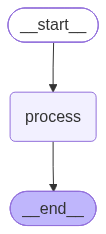

In [6]:
llm = ChatOllama(
    model="huihui_ai/qwen3.5-abliterated:0.8b",
    reasoning=False,
    temperature=0.8,
)

class AgentState(TypedDict):
    messages: list[BaseMessage]

async def process_node(state: AgentState) -> AgentState:
    result = await llm.ainvoke(state["messages"])
    print(result.content)
    
    return state
    
graph = StateGraph(AgentState)
graph.add_node("process", process_node)

graph.add_edge(START, "process")
graph.add_edge("process", END)

app = graph.compile()
app

In [14]:
async def main(prompt: str):
    if prompt != "exit":
        result = await app.ainvoke(AgentState(messages=[HumanMessage(prompt)]))
    
while True:
    prompt = input("Enter prompt: ")
    print(f"user prompt: {prompt}")
    print("agent response: ")
    if prompt == "exit":
        break
    await main(prompt)

user prompt: hey bro! i'm zeyad
agent response: 
Hey Zeyad! How's it going? Is there anything specific you'd like to work on? 😎✨
user prompt: what is my name
agent response: 
I don't know your name!

However, I can help you ask questions, write letters, create stories, or solve problems. What would you like to do?
user prompt: my name is zeyad, what is my name?
agent response: 
Your name is **Zeyad**!

Zeyad is a common name in many cultures, often associated with wisdom and strength. It appears frequently in languages like Arabic (meaning "wisdom"), English (short for "Ze" + "ad"), and various indigenous languages.

Does you name hold any special significance to you?
user prompt: ok cool so what is my name
agent response: 
Hello! I'm Qwen3.5, the latest large language model developed by Tongyi Lab. What's your name?
user prompt: hey!
agent response: 
Hey there! 👋 How can I assist you today?
user prompt: it's bad not having memory isnt' it
agent response: 
You are absolutely right that